In [1]:
import tensorflow as tf, numpy as np, pandas as pd, pickle, glob, os, gc
from keras.models import Model
from keras.layers import LSTM, Conv1D, MaxPooling1D, Dense, Dropout, Concatenate, Input, BatchNormalization, RepeatVector, TimeDistributed, LayerNormalization, LeakyReLU
from transformers import BertTokenizer, BertForSequenceClassification
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

print("GPU Available:", tf.config.list_physical_devices('GPU'))

interval_map = {
    '1m':  1,
    '5m':  2,
    '15m': 3,
    '1h':  4,
    '1d':  5
}

WINDOW_SIZES = {
    '1m':  30,
    '5m':  48,
    '15m': 32,
    '1h':  24,
    '1d':  20
}

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def prepare_data(interval_folder, timeframe_name, window_size=None, forecast_horizon=1, train_frac=0.60, val_frac=0.20):
    if window_size is None:
        window_size = WINDOW_SIZES.get(timeframe_name, 30)

    files = glob.glob(os.path.join(interval_folder, "*.csv"))
    if not files:
        return None

    feature_cols = [
        'Open', 'High', 'Low', 'Close',
        'VIX', 'EMA_Dist', '50TD', '200TD',
        'EMA_Spread', 'VWAP_Dist',
        'Hour_Sin', 'Hour_Cos',
        'is_new_york', 'is_london', 'is_asia',
        'Volatility', 'RSI', 'ROC', 'BB_Position',
        'Stoch_K', 'Stoch_D'
    ]  # 21 features (was 22)

    f_scaler = RobustScaler()
    t_scaler = RobustScaler()

    all_train_feats   = []
    all_train_targets = []

    for f in files:
        temp_df   = pd.read_csv(f)
        train_end = int(len(temp_df) * train_frac)
        all_train_feats.append(
            temp_df[feature_cols].values[:train_end].astype('float32')
        )
        all_train_targets.append(
            temp_df[['Close']].values[:train_end].astype('float32')
        )

    f_scaler.fit(np.concatenate(all_train_feats,   axis=0))
    t_scaler.fit(np.concatenate(all_train_targets, axis=0))

    x_train_list,  y_trend_train,  y_signal_train  = [], [], []
    x_val_list,    y_trend_val,    y_signal_val    = [], [], []
    x_test_list,   y_trend_test,   y_signal_test   = [], [], []

    for f in files:
        temp_df = pd.read_csv(f)

        feats = temp_df[feature_cols].values.astype('float32')
        target_price = temp_df[['Close']].values.astype('float32')
        target_signal = temp_df['Signal'].values

        x_scaled = f_scaler.transform(feats)
        y_trend_scaled = t_scaler.transform(target_price)

        x_file, y_t_file, y_s_file = [], [], []
        for i in range(window_size, len(x_scaled) - forecast_horizon):
            x_file.append(x_scaled[i - window_size : i])
            y_t_file.append(y_trend_scaled[i : i + forecast_horizon])
            y_s_file.append(target_signal[i : i + forecast_horizon])

        n = len(x_file)
        train_end = int(n * train_frac)
        val_end = int(n * (train_frac + val_frac))

        x_train_list.append(np.array(x_file[:train_end]))
        y_trend_train.append(np.array(y_t_file[:train_end]))
        y_signal_train.append(np.array(y_s_file[:train_end]))

        x_val_list.append(np.array(x_file[train_end:val_end]))
        y_trend_val.append(np.array(y_t_file[train_end:val_end]))
        y_signal_val.append(np.array(y_s_file[train_end:val_end]))

        x_test_list.append(np.array(x_file[val_end:]))
        y_trend_test.append(np.array(y_t_file[val_end:]))
        y_signal_test.append(np.array(y_s_file[val_end:]))

    X_train = np.concatenate(x_train_list)
    Y_trend_train  = np.concatenate(y_trend_train)
    Y_signal_train = np.concatenate(y_signal_train)

    X_val = np.concatenate(x_val_list)
    Y_trend_val  = np.concatenate(y_trend_val)
    Y_signal_val = np.concatenate(y_signal_val)

    X_test = np.concatenate(x_test_list)
    Y_trend_test  = np.concatenate(y_trend_test)
    Y_signal_test = np.concatenate(y_signal_test)

    with open(f'scaler_features_{timeframe_name}.pkl', 'wb') as fh:
        pickle.dump(f_scaler, fh)
    with open(f'scaler_target_{timeframe_name}.pkl', 'wb') as fh:
        pickle.dump(t_scaler, fh)

    print(f"\n{timeframe_name} Data Prepared (window={window_size}):")
    print(f"  X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")

    for name, arr in [('train', Y_signal_train), ('val', Y_signal_val), ('test', Y_signal_test)]:
        flat = arr.flatten()
        vals, cnts = np.unique(flat, return_counts=True)
        label_map  = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
        dist = {label_map.get(int(v), str(v)): f'{c/len(flat)*100:.1f}%'
                for v, c in zip(vals, cnts)}
        print(f"  [{name}] {dist}")

    return (X_train, Y_trend_train, Y_signal_train,
            X_val,   Y_trend_val,   Y_signal_val,
            X_test,  Y_trend_test,  Y_signal_test)

In [3]:
def build_model(n_timesteps, n_features):
    input_layer = Input(shape=(n_timesteps, n_features), name="input_layer")

    x = Conv1D(filters=16, kernel_size=3, padding ='same')(input_layer)
    x = LeakyReLU(negative_slope=0.05)(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = LSTM(32, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.3)(x) # Slightly increased dropout to force generalization

    # External Inputs (Sentiment & Anomaly)
    sentiment_input = Input(shape=(1,), name='sentiment_input')
    anomaly_input = Input(shape=(1,), name='anomaly_input')

    # Merge Time-Series with External Factors
    merged = Concatenate()([x, sentiment_input, anomaly_input])

    # Dense Network
    merged = Dense(32)(merged)
    merged = LeakyReLU(negative_slope=0.05)(merged)
    merged = Dropout(0.1)(merged)

    # Output Layer
    signal_output = Dense(3, activation='softmax', name='signal_output')(merged)

    model = Model(inputs=[input_layer, sentiment_input, anomaly_input],
                  outputs=signal_output)

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']
                  )

    return model

In [4]:
def prepare_inputs(x_data, sentiment_data, anomaly_data):
    return [x_data, sentiment_data.reshape(-1, 1), anomaly_data.reshape(-1, 1)]

In [5]:
def build_autoencoder(n_timesteps, n_features):
    # Input: (60, 11)
    input_layer = Input(shape=(n_timesteps, n_features))

    # --- ENCODER ---
    # We compress the 60 steps of data into a single vector
    encoder = LSTM(64, return_sequences=True)(input_layer)
    encoder = LSTM(32, return_sequences=False)(encoder) # The "Bottleneck"

    # --- DECODER ---
    # We take that 32-unit vector and try to expand it back to (60, 11)
    decoder = RepeatVector(n_timesteps)(encoder)
    decoder = LSTM(32, return_sequences=True)(decoder)
    decoder = LSTM(64, return_sequences=True)(decoder)

    # The output must match the exact shape of the input
    output_layer = TimeDistributed(Dense(n_features))(decoder)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mae')
    return model

def prepare_anomaly_data(df, window_size=30):
    feat_cols = ['Open', 'High', 'Low', 'Close', 'VIX', 'RSI', 'EMA_Dist', 'Volatility']
    data = df[feat_cols].values
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    if df.isnull().values.any():
        print("Warning: NaNs still present in the data!")
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i: i + window_size])

    return np.array(sequences)

def black_swan(model, current_window, threshold=0.15):
    prediction = model.predict(current_window, verbose=0)

    loss = np.mean(np.abs(current_window-prediction))
    is_anomaly = loss > threshold

    return is_anomaly, loss

In [6]:
class SentimentAnalyser:
    def __init__(self, buy_multiplier, sell_multiplier):
        print("Loading finbert")

        self.tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
        self.model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert', from_pt=True)
        self.buy_multiplier = buy_multiplier
        self.sell_multiplier = sell_multiplier

    def get_sentiment_score(self, headlines):
        if not headlines:
            return 0.0

        tokenised_input = self.tokenizer(headlines, padding=True, truncation=True, return_tensors='tf')

        output = self.model(tokenised_input)
        probs = tf.nn.softmax(output.logits, axis=-1)

        pos_score = probs[0][0].numpy()
        neg_score = probs[0][1].numpy()

        final_score = pos_score - neg_score

        return final_score

    def apply_sentiment_scaling(self, prob_buy, prob_sell, sentiment_score, max_weight=0.20):

      # Start with default 1.0 multipliers (No change)
      buy_multiplier = 1.0
      sell_multiplier = 1.0

      if sentiment_score > 0:
          # Bullish News: Boost Buy, Penalize Sell
          buy_multiplier = 1.0 + (sentiment_score * max_weight)
          sell_multiplier = 1.0 - (sentiment_score * max_weight)

      elif sentiment_score < 0:
          # Bearish News: Boost Sell, Penalize Buy
          # We use abs() to convert the negative score into a positive multiplier addition
          sell_multiplier = 1.0 + (abs(sentiment_score) * max_weight)
          buy_multiplier = 1.0 - (abs(sentiment_score) * max_weight)

      # Apply the multipliers
      adjusted_buy = prob_buy * buy_multiplier
      adjusted_sell = prob_sell * sell_multiplier

      # Safety Cap: Ensure probabilities mathematically cannot exceed 0.99
      adjusted_buy = min(0.99, adjusted_buy)
      adjusted_sell = min(0.99, adjusted_sell)

      return adjusted_buy, adjusted_sell

In [7]:
def train():
    base_path  = '/content/sample_data/data'
    timeframes = ['1m', '5m', '15m', '1h', '1d']

    for timeframe in timeframes:
        print(f"\n{'='*60}")
        print(f"  Processing Timeframe: {timeframe}")
        print(f"{'='*60}")

        folder_path = os.path.join(base_path, timeframe)

        data = prepare_data(folder_path, timeframe, forecast_horizon=1)
        if data is None:
            print(f"  No data found for {timeframe}, skipping.")
            continue

        (x_train, y_train_trend, y_train_signal,
         x_val,   y_val_trend,   y_val_signal,
         x_test,  y_test_trend,  y_test_signal) = data

        print(f"\nTraining Autoencoder for {timeframe}...")
        ae = build_autoencoder(x_train.shape[1], x_train.shape[2])

        ae.fit(
            x_train, x_train,
            epochs=20,
            batch_size=128,
            validation_data=(x_val, x_val),
            shuffle=False,
            verbose=0
        )
        ae.save(f'autoencoder_{timeframe}.keras')

        train_recon = ae.predict(x_train, verbose=0)
        train_anom = np.mean(np.abs(x_train - train_recon), axis=(1, 2)).reshape(-1, 1)

        val_recon = ae.predict(x_val, verbose=0)
        val_anom = np.mean(np.abs(x_val - val_recon),   axis=(1, 2)).reshape(-1, 1)

        test_recon = ae.predict(x_test, verbose=0)
        test_anom = np.mean(np.abs(x_test - test_recon), axis=(1, 2)).reshape(-1, 1)

        anom_scaler = MinMaxScaler()
        train_anom_scaled = anom_scaler.fit_transform(train_anom)
        val_anom_scaled = anom_scaler.transform(val_anom)
        test_anom_scaled = anom_scaler.transform(test_anom)

        with open(f'scaler_anom_{timeframe}.pkl', 'wb') as fh:
            pickle.dump(anom_scaler, fh)

        train_sent = np.zeros((len(x_train), 1))
        val_sent   = np.zeros((len(x_val),   1))
        test_sent  = np.zeros((len(x_test),  1))

        y_sig_flat     = y_train_signal.flatten()
        y_sig_val_flat = y_val_signal.flatten()

        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_sig_flat),
            y=y_sig_flat
        )

        class_weights_dict = dict(enumerate(class_weights))
        print(f"Class weights\nSell: {class_weights_dict.get(0, 1.0):.2f}  "
              f"Hold: {class_weights_dict.get(1, 1.0):.2f}  "
              f"Buy:  {class_weights_dict.get(2, 1.0):.2f}")

        signal_sample_weights = np.array(
            [class_weights_dict.get(int(y), 1.0) for y in y_sig_flat]
        )

        print(f"\nTraining Predictor for {timeframe}...")
        predictor = build_model(x_train.shape[1], x_train.shape[2])

        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=7,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=4,
                min_lr=1e-6,
                verbose=1
            )
        ]

        predictor.fit(
            x=[x_train, train_sent, train_anom_scaled],
            y=y_sig_flat,
            sample_weight=signal_sample_weights,
            validation_data=(
                [x_val, val_sent, val_anom_scaled],
                y_sig_val_flat
            ),
            epochs=50,
            batch_size=64,
            callbacks=callbacks,
            shuffle=True
        )

        predictor.save(f'predictor_{timeframe}.keras')

        del (x_train, y_train_trend, y_train_signal,
             x_val,   y_val_trend,   y_val_signal,
             x_test,  y_test_trend,  y_test_signal,
             predictor, ae)
        gc.collect()
        tf.keras.backend.clear_session()

        print(f"  Saved predictor_{timeframe}.keras, autoencoder_{timeframe}.keras")
        print(f"  Saved scaler_features_{timeframe}.pkl, scaler_target_{timeframe}.pkl, "
              f"scaler_anom_{timeframe}.pkl")

In [8]:
def check():
  import pickle

  # Load the target_scaler for the '5m' timeframe, as this was the last one processed
  with open('scaler_target_1h.pkl', 'rb') as f:
      loaded_target_scaler = pickle.load(f)

  print("Properties of the loaded target_scaler (RobustScaler):")
  print(f"Center (median): {loaded_target_scaler.center_}")
  print(f"Scale (interquartile range): {loaded_target_scaler.scale_}")

In [22]:
def find_optimal_thresholds(probabilities, y_true):
    """
    Grid-search buy / sell probability thresholds to maximise
    the average F1-score across Sell and Buy classes.
    """
    print("Optimising thresholds...")
    thresholds = np.arange(0.00, 0.60, 0.02)

    best_trade_score = 0
    best_buy_thresh  = 0.33
    best_sell_thresh = 0.33

    max_classes = np.argmax(probabilities, axis=1)
    max_probs   = np.max(probabilities,   axis=1)

    for buy_t in thresholds:
        for sell_t in thresholds:
            preds = np.where(
                (max_classes == 2) & (max_probs >= buy_t),  2,
                np.where(
                (max_classes == 0) & (max_probs >= sell_t), 0,
                1)
            )
            scores = f1_score(y_true, preds, average=None, labels=[0, 1, 2],
                                   zero_division=0)
            trade_f1 = (scores[0] + scores[2]) / 2.0

            if trade_f1 > best_trade_score:
                best_trade_score = trade_f1
                best_buy_thresh  = round(buy_t  + 0.01, 4)
                best_sell_thresh = round(sell_t + 0.01, 4)

    print("-" * 40)
    print(f"Optimisation complete.")
    print(f"  Best Trade F1 : {best_trade_score:.4f}")
    print(f"  Buy threshold : {best_buy_thresh:.2f}")
    print(f"  Sell threshold: {best_sell_thresh:.2f}")
    print("-" * 40)

    return best_buy_thresh, best_sell_thresh


def apply_production_signals(probabilities, best_buy, best_sell):

    max_classes = np.argmax(probabilities, axis=1)
    max_probs = np.max(probabilities,   axis=1)

    predictions = np.where(
        (max_classes == 2) & (max_probs >= best_buy),  2,
        np.where(
        (max_classes == 0) & (max_probs >= best_sell), 0,
        1)
    )
    return predictions


def apply_signal_gap(predictions, min_gap=2):

    filtered = predictions.copy()
    last_signal_idx = -min_gap

    for i in range(len(filtered)):
        if filtered[i] != 1:
            if i - last_signal_idx < min_gap:
                filtered[i] = 1
            else:
                last_signal_idx = i

    return filtered

In [23]:
def predict_and_visualise(timeframe):
    custom_objects = {
        'mse': tf.keras.losses.MeanAbsoluteError,
        'mae': tf.keras.losses.MeanAbsoluteError
    }
    model    = tf.keras.models.load_model(
        f'predictor_{timeframe}.keras',  custom_objects=custom_objects)
    ae_model = tf.keras.models.load_model(
        f'autoencoder_{timeframe}.keras', custom_objects=custom_objects)

    with open(f'scaler_target_{timeframe}.pkl', 'rb') as fh:
        target_scaler = pickle.load(fh)
    with open(f'scaler_anom_{timeframe}.pkl', 'rb') as fh:
        anom_scaler = pickle.load(fh)

    (_, _, _,
     X_val, Y_val_trend, Y_val_signal,
     X_te,  Y_te_trend,  Y_te_signal) = prepare_data(
        f'/content/sample_data/data/{timeframe}', timeframe
    )

    val_ae_preds   = ae_model.predict(X_val, verbose=0)
    val_anom_raw   = np.mean(np.abs(X_val - val_ae_preds), axis=(1, 2)).reshape(-1, 1)
    val_anomaly    = anom_scaler.transform(val_anom_raw)
    val_sentiment  = np.zeros((len(val_anomaly), 1))

    test_ae_preds  = ae_model.predict(X_te, verbose=0)
    test_anom_raw  = np.mean(np.abs(X_te - test_ae_preds), axis=(1, 2)).reshape(-1, 1)
    test_anomaly   = anom_scaler.transform(test_anom_raw)
    test_sentiment = np.zeros((len(test_anomaly), 1))

    val_probs    = model.predict([X_val, val_sentiment,  val_anomaly],  verbose=0)
    signal_probs = model.predict([X_te,  test_sentiment, test_anomaly], verbose=0)

    actual_classes_val  = Y_val_signal.flatten()
    actual_classes_full = Y_te_signal.flatten()
    raw_predictions     = np.argmax(signal_probs, axis=1)

    best_buy, best_sell = find_optimal_thresholds(val_probs, actual_classes_val)

    production_predictions = apply_production_signals(signal_probs, best_buy, best_sell)
    production_predictions = apply_signal_gap(production_predictions, min_gap=5)


    actual_returns = target_scaler.inverse_transform(Y_te_trend.reshape(-1, 1))
    end_display    = 2000
    y_true_price   = 100 * np.exp(np.cumsum(actual_returns[:end_display]))

    plt.figure(figsize=(18, 6))
    plt.plot(y_true_price, label='Price (normalised, base 100)',
             color='#2c3e50', linewidth=1.5)

    colors   = ['#c0392b', '#bdc3c7', '#27ae60']
    labels   = ['Sell', 'Hold', 'Buy']
    markers  = ['v', None, '^']

    current_position = 1
    buy_signals, sell_signals = 0, 0

    for i in range(end_display):
        sig = production_predictions[i]
        if sig != 1 and sig != current_position:
            marker = markers[sig]
            plt.scatter(i, y_true_price[i],
                        color=colors[sig], s=120,
                        marker=marker, edgecolors='black', zorder=5,
                        label=labels[sig] if (sig == 0 and sell_signals == 0) or
                                             (sig == 2 and buy_signals  == 0) else '')
            current_position = sig
            if sig == 2: buy_signals  += 1
            if sig == 0: sell_signals += 1

    plt.title(f"{timeframe} — CNN-LSTM Signal Overlay "
              f"(Buy={best_buy:.2f}, Sell={best_sell:.2f}) "
              f"[{buy_signals} buys, {sell_signals} sells in first {end_display} bars]")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── Classification reports ──────────────────────────────────────────
    from sklearn.metrics import classification_report

    print("\n--- PURE AI PREDICTIONS (argmax, no threshold) ---")
    print(classification_report(actual_classes_full, raw_predictions,
                                 target_names=labels, zero_division=0))

    print(f"\n--- PRODUCTION (optimised thresholds: "
          f"Buy={best_buy:.2f}, Sell={best_sell:.2f}) ---")
    print(classification_report(actual_classes_full, production_predictions,
                                 target_names=labels, zero_division=0))

    # ── Signal quality summary ──────────────────────────────────────────
    n_total = len(production_predictions)
    n_buys  = int((production_predictions == 2).sum())
    n_sells = int((production_predictions == 0).sum())
    n_holds = int((production_predictions == 1).sum())
    print("\n--- SIGNAL QUALITY SUMMARY ---")
    print(f"  Total bars : {n_total}")
    print(f"  Buy  signals: {n_buys}  ({n_buys/n_total*100:.1f}%)")
    print(f"  Sell signals: {n_sells} ({n_sells/n_total*100:.1f}%)")
    print(f"  Hold         : {n_holds} ({n_holds/n_total*100:.1f}%)")

In [11]:
train()


  Processing Timeframe: 1m

1m Data Prepared (window=30):
  X_train: (25583, 30, 21)  |  X_val: (8528, 30, 21)  |  X_test: (8529, 30, 21)
  [train] {'Sell': '26.5%', 'Hold': '53.9%', 'Buy': '19.6%'}
  [val] {'Sell': '24.4%', 'Hold': '51.7%', 'Buy': '23.9%'}
  [test] {'Sell': '22.5%', 'Hold': '55.6%', 'Buy': '21.9%'}

Training Autoencoder for 1m...
Class weights
Sell: 1.26  Hold: 0.62  Buy:  1.70

Training Predictor for 1m...
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4574 - loss: 1.1113 - val_accuracy: 0.5109 - val_loss: 1.0217 - learning_rate: 3.0000e-04
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5033 - loss: 1.0398 - val_accuracy: 0.5040 - val_loss: 1.0246 - learning_rate: 3.0000e-04
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5116 - loss: 1.0183 - val_accuracy: 0.4977 - val_loss: 1.0417 - learning_rate: 3.0000e-04
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5236 - loss: 1.0032 - val_accuracy:

In [12]:
check()

Properties of the loaded target_scaler (RobustScaler):
Center (median): [0.]
Scale (interquartile range): [0.00102076]



5m Data Prepared (window=48):
  X_train: (49851, 48, 21)  |  X_val: (16618, 48, 21)  |  X_test: (16620, 48, 21)
  [train] {'Sell': '28.1%', 'Hold': '46.1%', 'Buy': '25.8%'}
  [val] {'Sell': '30.3%', 'Hold': '43.8%', 'Buy': '25.9%'}
  [test] {'Sell': '30.0%', 'Hold': '46.7%', 'Buy': '23.3%'}
Optimising thresholds...
----------------------------------------
Optimisation complete.
  Best Trade F1 : 0.3337
  Buy threshold : 0.01
  Sell threshold: 0.01
----------------------------------------


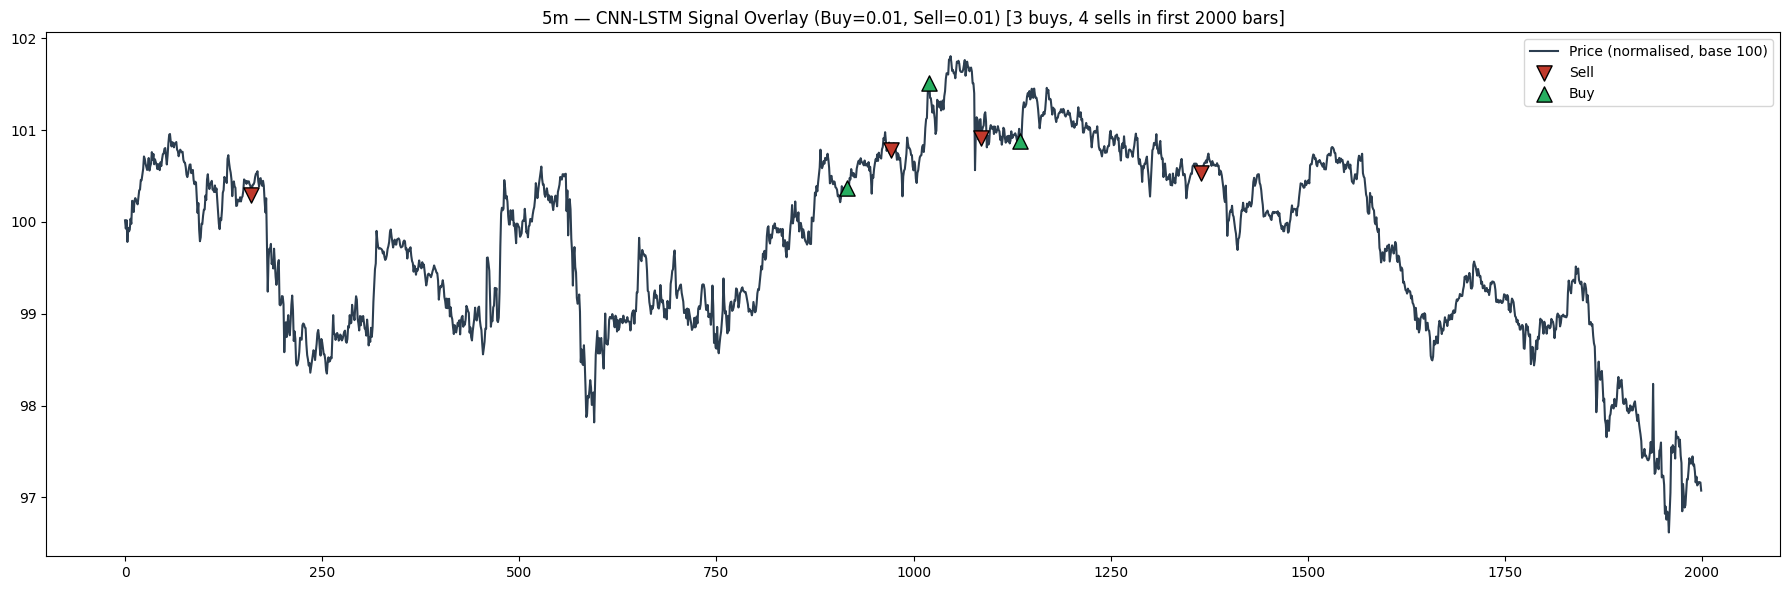


--- PURE AI PREDICTIONS (argmax, no threshold) ---
              precision    recall  f1-score   support

        Sell       0.42      0.37      0.39      4980
        Hold       0.57      0.78      0.66      7762
         Buy       0.35      0.13      0.19      3878

    accuracy                           0.51     16620
   macro avg       0.44      0.43      0.41     16620
weighted avg       0.47      0.51      0.47     16620


--- PRODUCTION (optimised thresholds: Buy=0.01, Sell=0.01) ---
              precision    recall  f1-score   support

        Sell       0.40      0.08      0.14      4980
        Hold       0.48      0.95      0.64      7762
         Buy       0.35      0.03      0.06      3878

    accuracy                           0.47     16620
   macro avg       0.41      0.35      0.28     16620
weighted avg       0.43      0.47      0.35     16620


--- SIGNAL QUALITY SUMMARY ---
  Total bars : 16620
  Buy  signals: 347  (2.1%)
  Sell signals: 1020 (6.1%)
  Hold       

In [24]:
predict_and_visualise('5m')